In [139]:
import pandas  as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [140]:
df = pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [141]:
df = df.drop(["Gender"], axis=1)
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


In [142]:
df.isna().sum()

Height    0
Weight    0
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(0)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  10000 non-null  float64
 1   Weight  10000 non-null  float64
dtypes: float64(2)
memory usage: 156.4 KB


In [145]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


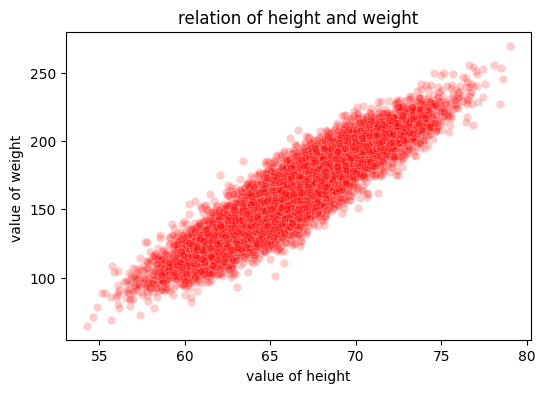

In [146]:
# visualize the data 
plt.figure(figsize=(6,4))
sns.scatterplot(x= df["Height"], y =df["Weight"], color = "r", alpha=.2)
plt.xlabel("value of height")
plt.ylabel("value of weight ")
plt.title("relation of height and weight")
plt.show()

In [147]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


# preprocessing 


In [148]:
std = StandardScaler()
for col in df.columns:
    df[col]= std.fit_transform(df[[col]])

In [149]:
df.head()

,Height,Weight
0,1.944061,2.505797
1,0.627537,0.027101
2,2.012443,1.597806
3,1.394060,1.825222
4,0.913421,1.398750


In [150]:
df.diupnm fc

SyntaxError: invalid syntax (4152852391.py, line 1)

<Axes: >

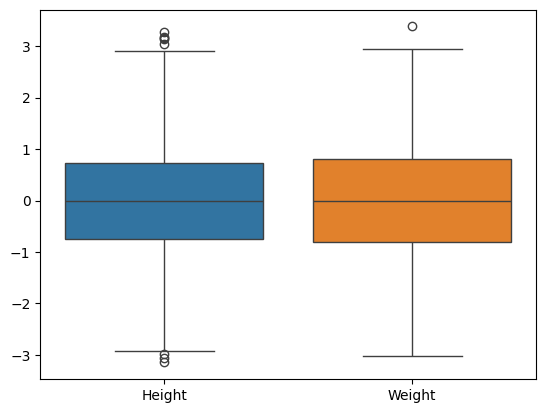

In [151]:
sns.boxplot(df)

In [160]:
def outlier_rem(df, col):
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)

    iqr = q3-q1

    lower_whisker= q1-1.5*iqr
    upper_wishker= q3+1.5*iqr

    return df[(lower_whisker <= df[col]) & (df[col] <= upper_wishker)]

In [161]:
new_df= outlier_rem(df, "Height")

In [162]:
new_df.shape

(9992, 2)

<Axes: >

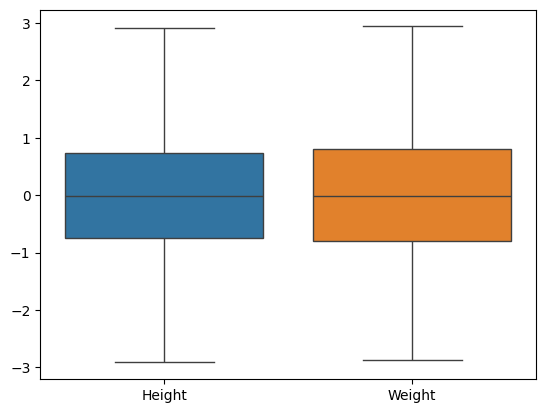

In [ ]:
sns.boxplot(new_df)

In [164]:
df = new_df.copy()

In [165]:
# separate the data 
x = df[["Height"]]
y = df[["Weight"]]

In [166]:
# split the data 
xtrain, xtest, ytrain, ytest = train_test_split(x,y,  train_size=.8, random_state=2000000000)

In [167]:
xtrain.head()

,Height
5194,-0.954201
7447,-2.064371
9234,-0.754842
2587,0.437307
7325,-0.591146


In [168]:
ytrain.head()

,Weight
5194,-0.842325
7447,-1.734380
9234,-0.728851
2587,0.366150
7325,-1.028523


In [169]:
# model implement 
lr_model = LinearRegression() # instance of model 
lr_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [170]:
# train  model 
model = lr_model.fit(xtrain, ytrain)

In [171]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [172]:
model.score(xtrain, ytrain) # training score

0.8537201261252612

In [173]:
model.score(xtest, ytest) # test score

0.8567248685569168

In [174]:
m = model.coef_

In [175]:
m

array([[0.92394559]])

In [176]:
c= model.intercept_

In [177]:
c

array([0.00069628])

In [178]:
df.head()

,Height,Weight
0,1.944061,2.505797
1,0.627537,0.027101
2,2.012443,1.597806
3,1.394060,1.825222
4,0.913421,1.398750


In [179]:
m*73.84 +c

array([[68.22483892]])

In [180]:
model.predict([[73.84]])

c:\Users\CreativeIT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[68.22483892]])

In [181]:
pred = model.predict(xtest)

In [182]:
pred

array([[-1.14653543],
       [-1.26107746],
       [-0.78425758],
       ...,
       [-0.71421864],
       [ 0.72446324],
       [-0.82204123]], shape=(1999, 1))

In [183]:
ytest

,Weight
8694,-1.118846
7182,-1.464078
9205,-0.887113
5538,-0.309579
501,0.661325
...,...
5854,-0.328668
2210,0.436412
6181,-1.586179
1098,1.116307


In [184]:
mse = mean_squared_error(ytest, pred)

In [185]:
mse

0.1450985894845244

In [186]:
mae = mean_absolute_error(ytest, pred)
mae

0.304586714868833

In [187]:
df["prediction"]= model.predict(df[["Height"]])

In [188]:
df.head()

,Height,Weight,prediction
0,1.944061,2.505797,1.796903
1,0.627537,0.027101,0.580506
2,2.012443,1.597806,1.860085
3,1.394060,1.825222,1.288732
4,0.913421,1.398750,0.844647


In [189]:
df["error"]= df["Weight"]- df["prediction"]
df.head()

,Height,Weight,prediction,error
0,1.944061,2.505797,1.796903,0.708894
1,0.627537,0.027101,0.580506,-0.553405
2,2.012443,1.597806,1.860085,-0.262278
3,1.394060,1.825222,1.288732,0.536490
4,0.913421,1.398750,0.844647,0.554103


<Axes: xlabel='Height', ylabel='prediction'>

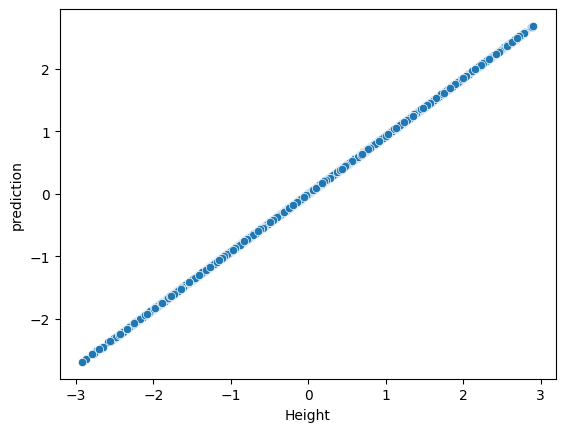

In [190]:
sns.scatterplot(x=df["Height"], y = df["prediction"])

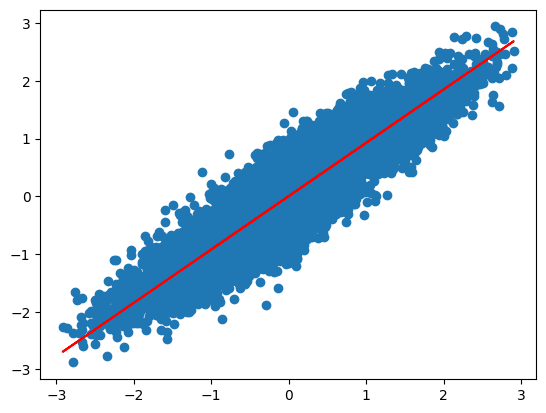

In [191]:
plt.scatter(df["Height"], df["Weight"])
plt.plot(df["Height"], df["prediction"], color="r")

In [192]:
test = int(input("enter a value for height   "))
test

478

In [194]:
model.predict([[test]])

c:\Users\CreativeIT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[441.64669011]])

In [ ]:

test_data = {"Height": [750]}
test_data

{'Height': [750]}

In [198]:
data = pd.DataFrame(test_data)
data

,Height
0,750


In [199]:
model.predict(data)

array([[692.95989163]])

In [200]:
import pickle
pickle.dump(model, open("height.pkl", "wb"))